# Inform II: Text and Image Data in Practice

This notebook demonstrates practical descriptive analysis of text and image data, focusing on basic algorithms and summary statistics.

## 1. Text Data: Data for Good Example

We'll use the Kaggle "Natural Language Processing with Disaster Tweets" dataset. This dataset contains tweets labeled as disaster-related or not, with the following columns:

- id: unique identifier for each tweet
- keyword: a keyword from the tweet (may be blank)
- location: location where the tweet was sent from (may be blank)
- text: the text of the tweet
- target: 1 if the tweet is about a real disaster, 0 if not (only in train.csv)

Source: https://www.kaggle.com/competitions/nlp-getting-started/data

In [6]:
# Read disaster tweets dataset from local data folder
import pandas as pd

train_path = '../data/train.csv'
test_path = '../data/test.csv'
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
display(df_train.head())
display(df_test.head())

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


### Basic Descriptive Stats for Text Data

Number of tweets: 7613
Number of disaster tweets: 3271
Number of non-disaster tweets: 4342
Unique keywords: 221
Unique locations: 3341
Average tweet length: 101.03743596479706
Percentage of disaster tweets: 42.96597924602653 %
Percentage of non-disaster tweets: 57.03402075397347 %


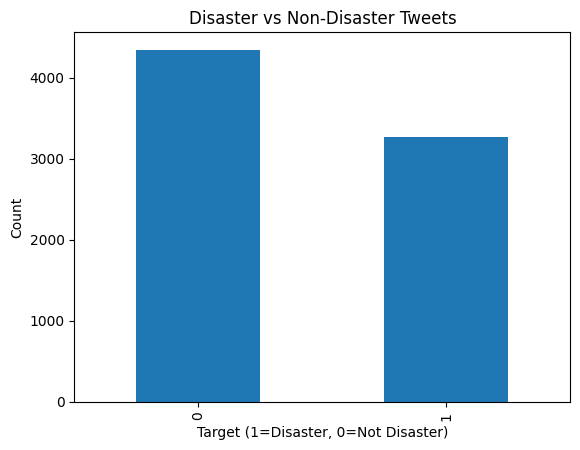

In [16]:
# Descriptive statistics for train data

import matplotlib.pyplot as plt

print('Number of tweets:', len(df_train))
print('Number of disaster tweets:', df_train['target'].sum())
print('Number of non-disaster tweets:', (df_train['target'] == 0).sum())
print('Unique keywords:', df_train['keyword'].nunique())
print('Unique locations:', df_train['location'].nunique())


df_train['text_length'] = df_train['text'].str.len()
print('Average tweet length:', df_train['text_length'].mean())
print('Percentage of disaster tweets:', (df_train['target'].sum() / len(df_train)) * 100, '%')
print('Percentage of non-disaster tweets:', ((df_train['target'] == 0).sum() / len(df_train)) * 100, '%')
df_train['target'].value_counts().plot(kind='bar', title='Disaster vs Non-Disaster Tweets')
plt.xlabel('Target (1=Disaster, 0=Not Disaster)')
plt.ylabel('Count')
plt.show()

In [25]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Basic text vectorization
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df_train['text'].fillna(''))
y = df_train['target']


In [26]:
# Train/test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [28]:
# Predict and evaluate
y_pred = model.predict(X_val)
y_pred

array([0, 0, 0, ..., 1, 1, 1])

In [29]:
# Display actual text from validation set - first 3 and last 3 items
print("First 3 items in validation set:")
print(df_train.loc[y_val.index[:3], 'text'].values)
print("\n" + "="*80 + "\n")
print("Last 3 items in validation set:")
print(df_train.loc[y_val.index[-3:], 'text'].values)

First 3 items in validation set:
['So you have a new weapon that can cause un-imaginable destruction.'
 'The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@'
 'DT @georgegalloway: RT @Galloway4Mayor: \x89ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q']


Last 3 items in validation set:
['Man charged over fatal crash near Dubbo refused bail http://t.co/HDBMfOVUtZ via @dailyliberal'
 '#usNWSgov Severe Weather Statement issued August 05 at 10:38PM EDT by NWS: ...THE SEVERE THUNDERSTORM WARNING ... http://t.co/7HuEN4rWrn'
 "Great British &lt;b&gt;Bake&lt;/b&gt; Off's back and Dorret's &lt;b&gt;chocolate&lt;/b&gt; gateau collapsed - JAN\x89Û_ http://t.co/53LORsrGqf"]


In [30]:
print('Validation Accuracy:', accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.7813525935653316
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       874
           1       0.78      0.68      0.73       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523



In [31]:
# Get the top words associated with disaster tweets
disaster_importances = model.coef_[0]
top_disaster_indices = np.argsort(disaster_importances)[-15:]
top_disaster_words = np.array(vectorizer.get_feature_names_out())[top_disaster_indices]
top_disaster_scores = disaster_importances[top_disaster_indices]

print("Top words used to describe disasters:")
for word, score in zip(top_disaster_words, top_disaster_scores):
    print(f"  {word}: {score:.4f}")

Top words used to describe disasters:
  buildings: 1.7258
  typhoon: 1.7847
  hailstorm: 1.8031
  suicide: 1.8125
  drought: 1.8241
  casualties: 1.8724
  rioting: 1.9179
  bombing: 1.9361
  tornado: 1.9968
  massacre: 2.1388
  derailment: 2.1656
  evacuated: 2.1712
  wildfire: 2.1900
  earthquake: 2.3316
  hiroshima: 2.5817


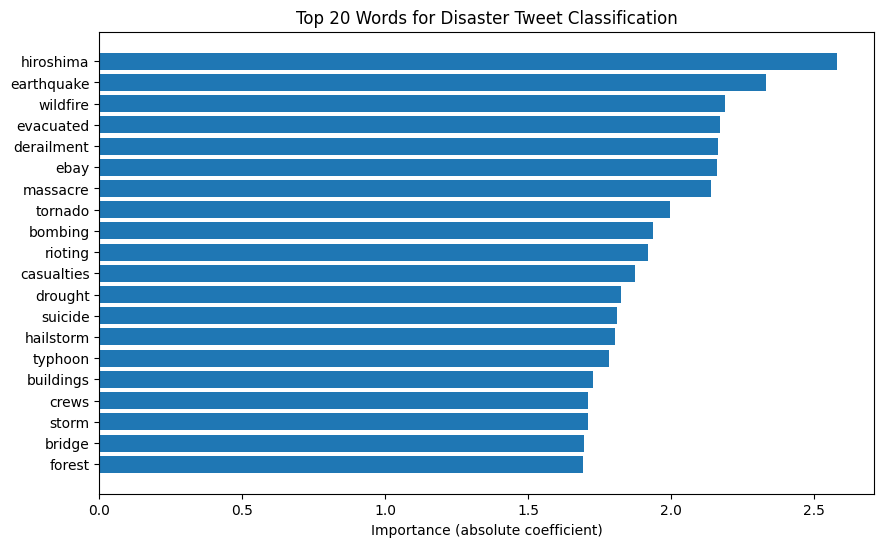

In [32]:
# Plot feature importances (top words)
importances = np.abs(model.coef_[0])
indices = np.argsort(importances)[-20:]
features = np.array(vectorizer.get_feature_names_out())[indices]
plt.figure(figsize=(10,6))
plt.barh(features, importances[indices])
plt.xlabel('Importance (absolute coefficient)')
plt.title('Top 20 Words for Disaster Tweet Classification')
plt.show()

### Alternative: Classification with a Pre-trained LLM (Hugging Face Transformers)
Let's use a lightweight pre-trained language model (e.g., DistilBERT) from Hugging Face to classify disaster tweets. This approach leverages transfer learning and modern NLP architectures.

#### What are Transformers?
Transformers are a type of deep learning model architecture that has revolutionized natural language processing (NLP). Introduced in the paper "Attention is All You Need" (Vaswani et al., 2017), transformers use a mechanism called self-attention to process input data in parallel and capture complex relationships between words in a sequence.

Key features of transformers:
- They do not require sequential data processing, making them faster to train than previous models like RNNs.
- They use self-attention to weigh the importance of different words in a sentence when making predictions.
- Transformers are the foundation for many state-of-the-art language models, such as BERT, GPT, and DistilBERT.

The Hugging Face Transformers library provides easy access to pre-trained transformer models for a wide range of NLP tasks, including text classification, question answering, and more.

In [33]:
# Hugging Face Transformers: Disaster Tweet Classification with DistilBERT
from transformers import pipeline
import torch

# Use GPU if available
device = 0 if torch.cuda.is_available() else -1

# Load zero-shot classification pipeline with a lightweight model
classifier = pipeline('zero-shot-classification', model='valhalla/distilbart-mnli-12-1', device=device)



Device set to use cpu


In [35]:
model

LogisticRegression()

In [34]:
classifier

In [36]:
# Example: classify a few tweets
candidate_labels = ['disaster', 'not disaster']
examples = df_train['text'].dropna().sample(5, random_state=42).tolist()
for text in examples:
    result = classifier(text, candidate_labels)
    print(f"Tweet: {text}\nLabel: {result['labels'][0]}, Score: {result['scores'][0]:.2f}\n")

Tweet: So you have a new weapon that can cause un-imaginable destruction.
Label: disaster, Score: 0.98

Tweet: The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@
Label: disaster, Score: 0.67

Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
Label: not disaster, Score: 0.94

Tweet: Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.
Label: not disaster, Score: 0.94

Tweet: in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3
Label: not disaster, Score: 0.61



In [42]:
# Run LLM on entire validation set and evaluate metrics
from sklearn.metrics import f1_score

true_labels = y_val.tolist()
texts = df_train.loc[y_val.index, 'text'].tolist()

pred_labels = []
for i, text in enumerate(texts):
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(texts)} texts")
    result = classifier(text, candidate_labels)
    pred = 1 if result['labels'][0] == 'disaster' else 0
    pred_labels.append(pred)

print('Accuracy:', accuracy_score(true_labels, pred_labels))
print('F1 Score:', f1_score(true_labels, pred_labels))
print(classification_report(true_labels, pred_labels, target_names=['not disaster', 'disaster']))


Processed 100/1523 texts
Processed 200/1523 texts
Processed 300/1523 texts
Processed 400/1523 texts
Processed 500/1523 texts
Processed 600/1523 texts
Processed 700/1523 texts
Processed 800/1523 texts
Processed 900/1523 texts
Processed 1000/1523 texts
Processed 1100/1523 texts
Processed 1200/1523 texts
Processed 1300/1523 texts
Processed 1400/1523 texts
Processed 1500/1523 texts
Accuracy: 0.6040709126723572
F1 Score: 0.6219435736677116
              precision    recall  f1-score   support

not disaster       0.73      0.49      0.58       874
    disaster       0.52      0.76      0.62       649

    accuracy                           0.60      1523
   macro avg       0.63      0.62      0.60      1523
weighted avg       0.65      0.60      0.60      1523

